# Tarea 4 - Modelo Logístico y Enfoque Bayesiano

**Estudiante:** Ivan Ramiro Quiroga Castañeda  
**Curso:** Métodos Estadísticos en la Ciencia de Datos y Analítica  
**Programa:** Especialización en Ciencia de Datos y Analítica  
**Universidad Nacional Abierta y a Distancia - UNAD**

In [4]:
# Carga de librerías y base de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

from scipy import stats

# Configuración general de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

df = pd.read_csv("Anexo 1 - Base de Datos dynamic_pricing.csv")

# Visualización inicial
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.4700,Night,Premium,90,284.2573
1,58,39,Suburban,Silver,72,4.0600,Evening,Economy,43,173.8748
2,42,31,Rural,Silver,0,3.9900,Afternoon,Premium,76,329.7955
3,89,28,Rural,Regular,67,4.3100,Afternoon,Premium,134,470.2012
4,78,22,Rural,Regular,74,3.7700,Afternoon,Economy,149,579.6814


In [5]:
# Revisión inicial de la base de datos

print("Dimensiones de la base de datos:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

print("\nValores nulos por variable:")
print(df.isnull().sum())

Dimensiones de la base de datos: (1000, 10)

Columnas disponibles:
['Number_of_Riders', 'Number_of_Drivers', 'Location_Category', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null 

## Preparación de variables para el modelo logístico

In [6]:

# Construcción de variables del modelo

# Variable de calificación del viaje
df["Trip_Rating"] = df["Average_Ratings"]

# Variable de distancia aproximada del viaje
df["Trip_Distance"] = df["Expected_Ride_Duration"]

# Recodificación binaria de Trip_Rating:
# 0 = servicio regular, calificación < 4
# 1 = servicio excelente, calificación >= 4
df["Trip_Rating_Binary"] = np.where(df["Trip_Rating"] >= 4, 1, 0)

# Codificación ordinal de Customer_Loyalty_Status
mapa_lealtad = {
    "Regular": 1,
    "Silver": 2,
    "Gold": 3
}

df["Customer_Loyalty"] = df["Customer_Loyalty_Status"].map(mapa_lealtad)

# Selección de variables solicitadas
df_model = df[
    [
        "Trip_Rating",
        "Trip_Rating_Binary",
        "Trip_Distance",
        "Number_of_Riders",
        "Customer_Loyalty",
        "Customer_Loyalty_Status",
        "Vehicle_Type"
    ]
].copy()

# Eliminación de registros nulos en las variables requeridas
df_model = df_model.dropna()
df_model.head()

,Trip_Rating,Trip_Rating_Binary,Trip_Distance,Number_of_Riders,Customer_Loyalty,Customer_Loyalty_Status,Vehicle_Type
0,4.4700,1,90,90,2,Silver,Premium
1,4.0600,1,43,58,2,Silver,Economy
2,3.9900,0,76,42,2,Silver,Premium
3,4.3100,1,134,89,1,Regular,Premium
4,3.7700,0,149,78,1,Regular,Economy


Distribución de Trip_Rating_Binary:
Trip_Rating_Binary
1    686
0    314
Name: count, dtype: int64

Distribución porcentual:
Trip_Rating_Binary
1   68.6000
0   31.4000
Name: proportion, dtype: float64


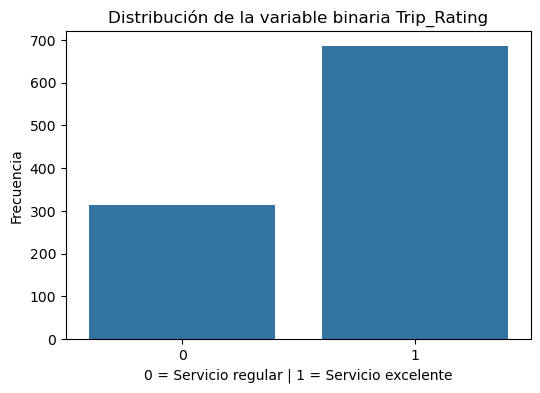

In [7]:

# Validación de la variable binaria

print("Distribución de Trip_Rating_Binary:")
print(df_model["Trip_Rating_Binary"].value_counts())

print("\nDistribución porcentual:")
print(df_model["Trip_Rating_Binary"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x="Trip_Rating_Binary")
plt.title("Distribución de la variable binaria Trip_Rating")
plt.xlabel("0 = Servicio regular | 1 = Servicio excelente")
plt.ylabel("Frecuencia")
plt.show()

## Ajuste del modelo de regresión logística binaria

En esta sección se ajusta un modelo de regresión logística binaria, tomando como variable dependiente `Trip_Rating_Binary`, donde 1 representa un servicio excelente y 0 representa un servicio regular. Como variables predictoras se utilizan `Trip_Distance`, `Number_of_Riders` y `Customer_Loyalty`, de acuerdo con lo solicitado en la guía de aprendizaje.

In [8]:

# Ajuste del modelo logístico completo

# Definir variable dependiente
y = df_model["Trip_Rating_Binary"]

# Definir variables predictoras
X = df_model[["Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]]

# Agregar constante para el intercepto
X_const = sm.add_constant(X)

# Ajustar modelo logístico binario
modelo_logit_completo = sm.Logit(y, X_const).fit()

# Mostrar resumen del modelo
print(modelo_logit_completo.summary())

Optimization terminated successfully.
         Current function value: 0.620510
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:     Trip_Rating_Binary   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Sun, 10 May 2026   Pseudo R-squ.:                0.002819
Time:                        18:47:06   Log-Likelihood:                -620.51
converged:                       True   LL-Null:                       -622.26
Covariance Type:            nonrobust   LLR p-value:                    0.3197
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.0935      0.298      3.673      0.000       0.510       1.677
Trip_Distan

In [10]:
# Tabla de coeficientes y significancia estadística

tabla_coeficientes = pd.DataFrame({
    "Coeficiente": modelo_logit_completo.params,
    "Error estándar": modelo_logit_completo.bse,
    "Valor z": modelo_logit_completo.tvalues,
    "p-valor": modelo_logit_completo.pvalues
})

tabla_coeficientes

,Coeficiente,Error estándar,Valor z,p-valor
const,1.0935,0.2977,3.6730,0.0002
Trip_Distance,-0.0024,0.0014,-1.7099,0.0873
Number_of_Riders,0.0007,0.0029,0.2509,0.8019
Customer_Loyalty,-0.0577,0.0859,-0.6715,0.5019


In [11]:

# Construcción de la ecuación del modelo
coef = modelo_logit_completo.params

print("Ecuación estimada del modelo logístico:")
print(
    f"logit(p) = {coef['const']:.4f} "
    f"+ ({coef['Trip_Distance']:.4f})*Trip_Distance "
    f"+ ({coef['Number_of_Riders']:.4f})*Number_of_Riders "
    f"+ ({coef['Customer_Loyalty']:.4f})*Customer_Loyalty"
)

print("\nDonde p representa la probabilidad de que el servicio sea calificado como excelente.")

Ecuación estimada del modelo logístico:
logit(p) = 1.0935 + (-0.0024)*Trip_Distance + (0.0007)*Number_of_Riders + (-0.0577)*Customer_Loyalty

Donde p representa la probabilidad de que el servicio sea calificado como excelente.


## Interpretación mediante Odds Ratios


In [12]:

# Cálculo de Odds Ratios

odds_ratios = np.exp(modelo_logit_completo.params)

tabla_or = pd.DataFrame({
    "Coeficiente": modelo_logit_completo.params,
    "Odds Ratio": odds_ratios,
    "p-valor": modelo_logit_completo.pvalues
})

tabla_or

,Coeficiente,Odds Ratio,p-valor
const,1.0935,2.9848,0.0002
Trip_Distance,-0.0024,0.9976,0.0873
Number_of_Riders,0.0007,1.0007,0.8019
Customer_Loyalty,-0.0577,0.9439,0.5019


## Matriz de confusión y métricas de desempeño

In [13]:

# División de datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

# Agregar constante
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajustar modelo con datos de entrenamiento
modelo_logit_train = sm.Logit(y_train, X_train_const).fit()

# Predicción de probabilidades sobre datos de prueba
y_prob = modelo_logit_train.predict(X_test_const)

# Clasificación usando umbral de 0.5
y_pred = np.where(y_prob >= 0.5, 1, 0)

# Matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)

matriz_confusion

Optimization terminated successfully.
         Current function value: 0.619389
         Iterations 5


array([[  0,  94],
       [  0, 206]], dtype=int64)

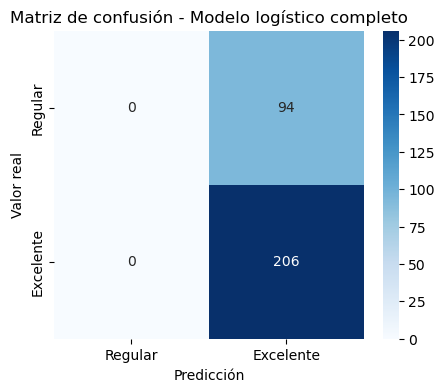

In [14]:

# Visualización de la matriz de confusión

plt.figure(figsize=(5, 4))
sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Regular", "Excelente"],
    yticklabels=["Regular", "Excelente"]
)

plt.title("Matriz de confusión - Modelo logístico completo")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [15]:

# Métricas de desempeño del modelo

tn, fp, fn, tp = matriz_confusion.ravel()

accuracy = accuracy_score(y_test, y_pred)
sensibilidad = recall_score(y_test, y_pred)
especificidad = tn / (tn + fp)

metricas_modelo = pd.DataFrame({
    "Métrica": ["Accuracy", "Sensibilidad / Recall", "Especificidad"],
    "Valor": [accuracy, sensibilidad, especificidad]
})

metricas_modelo

,Métrica,Valor
0,Accuracy,0.6867
1,Sensibilidad / Recall,1.0000
2,Especificidad,0.0000


## 2.2 Comparación de desempeño de modelos logísticos

In [16]:
# Ajuste del modelo logístico reducido

# Modelo reducido sin Number_of_Riders
X_reducido = df_model[["Trip_Distance", "Customer_Loyalty"]]
X_reducido_const = sm.add_constant(X_reducido)

# Ajuste del modelo reducido
modelo_logit_reducido = sm.Logit(y, X_reducido_const).fit()

# Resumen del modelo reducido
print(modelo_logit_reducido.summary())

Optimization terminated successfully.
         Current function value: 0.620541
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:     Trip_Rating_Binary   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                0.002768
Time:                        19:28:22   Log-Likelihood:                -620.54
converged:                       True   LL-Null:                       -622.26
Covariance Type:            nonrobust   LLR p-value:                    0.1786
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.1402      0.233      4.902      0.000       0.684       1.596
Trip_Distan

# Comparación de métricas de ajuste

In [18]:

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Modelo completo", "Modelo reducido"],
    "Variables": [
        "Trip_Distance + Number_of_Riders + Customer_Loyalty",
        "Trip_Distance + Customer_Loyalty"
    ],
    "Pseudo R² McFadden": [
        modelo_logit_completo.prsquared,
        modelo_logit_reducido.prsquared
    ],
    "AIC": [
        modelo_logit_completo.aic,
        modelo_logit_reducido.aic
    ],
    "Log-Likelihood": [
        modelo_logit_completo.llf,
        modelo_logit_reducido.llf
    ]
})

comparacion_modelos

,Modelo,Variables,Pseudo R² McFadden,AIC,Log-Likelihood
0,Modelo completo,Trip_Distance + Number_of_Riders + Customer_Lo...,0.0028,1249.0193,-620.5097
1,Modelo reducido,Trip_Distance + Customer_Loyalty,0.0028,1247.0823,-620.5411


## Evaluación predictiva del modelo reducido

In [20]:
# División de datos para el modelo reducido
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reducido,
    y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

# Agregar constante
X_train_red_const = sm.add_constant(X_train_red)
X_test_red_const = sm.add_constant(X_test_red)

# Ajustar modelo reducido con datos de entrenamiento
modelo_reducido_train = sm.Logit(y_train_red, X_train_red_const).fit()

# Predicción de probabilidades
y_prob_reducido = modelo_reducido_train.predict(X_test_red_const)

# Clasificación con umbral de 0.5
y_pred_reducido = np.where(y_prob_reducido >= 0.5, 1, 0)

# Matriz de confusión del modelo reducido
matriz_confusion_reducido = confusion_matrix(y_test_red, y_pred_reducido)

matriz_confusion_reducido

Optimization terminated successfully.
         Current function value: 0.619670
         Iterations 5


array([[  0,  94],
       [  0, 206]], dtype=int64)

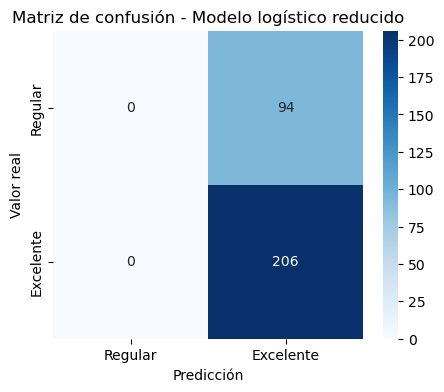

In [21]:
# Visualización matriz de confusión modelo reducido

plt.figure(figsize=(5, 4))
sns.heatmap(
    matriz_confusion_reducido,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Regular", "Excelente"],
    yticklabels=["Regular", "Excelente"]
)

plt.title("Matriz de confusión - Modelo logístico reducido")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [22]:
# Métricas de desempeño del modelo reducido

tn_red, fp_red, fn_red, tp_red = matriz_confusion_reducido.ravel()

accuracy_red = accuracy_score(y_test_red, y_pred_reducido)
sensibilidad_red = recall_score(y_test_red, y_pred_reducido)
especificidad_red = tn_red / (tn_red + fp_red)

metricas_modelo_reducido = pd.DataFrame({
    "Métrica": ["Accuracy", "Sensibilidad / Recall", "Especificidad"],
    "Valor": [accuracy_red, sensibilidad_red, especificidad_red]
})

metricas_modelo_reducido

,Métrica,Valor
0,Accuracy,0.6867
1,Sensibilidad / Recall,1.0000
2,Especificidad,0.0000


# Comparación de métricas de clasificación

In [23]:

comparacion_clasificacion = pd.DataFrame({
    "Modelo": ["Modelo completo", "Modelo reducido"],
    "Accuracy": [accuracy, accuracy_red],
    "Sensibilidad / Recall": [sensibilidad, sensibilidad_red],
    "Especificidad": [especificidad, especificidad_red]
})

comparacion_clasificacion

,Modelo,Accuracy,Sensibilidad / Recall,Especificidad
0,Modelo completo,0.6867,1.0000,0.0000
1,Modelo reducido,0.6867,1.0000,0.0000


# Curva ROC y AUC

AUC modelo completo: 0.4902
AUC modelo reducido: 0.498


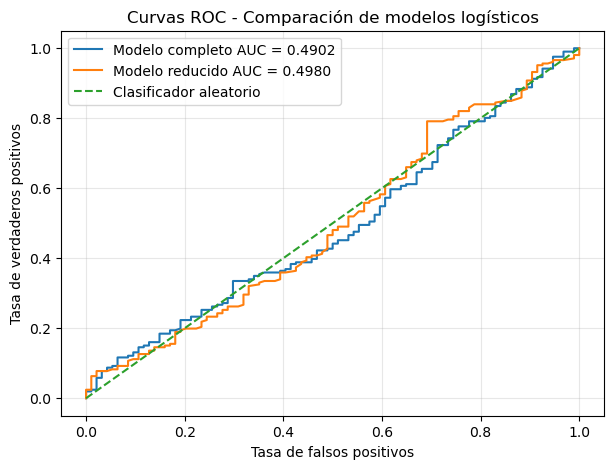

In [24]:
# Probabilidades del modelo completo ya entrenado con train/test anterior
y_prob_completo = modelo_logit_train.predict(X_test_const)

# Curvas ROC
fpr_completo, tpr_completo, _ = roc_curve(y_test, y_prob_completo)
fpr_reducido, tpr_reducido, _ = roc_curve(y_test_red, y_prob_reducido)

# AUC
auc_completo = roc_auc_score(y_test, y_prob_completo)
auc_reducido = roc_auc_score(y_test_red, y_prob_reducido)

print("AUC modelo completo:", round(auc_completo, 4))
print("AUC modelo reducido:", round(auc_reducido, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr_completo, tpr_completo, label=f"Modelo completo AUC = {auc_completo:.4f}")
plt.plot(fpr_reducido, tpr_reducido, label=f"Modelo reducido AUC = {auc_reducido:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.title("Curvas ROC - Comparación de modelos logísticos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Tabla final comparativa de modelos

In [25]:
tabla_final_comparacion = pd.DataFrame({
    "Modelo": ["Modelo completo", "Modelo reducido"],
    "Pseudo R² McFadden": [
        modelo_logit_completo.prsquared,
        modelo_logit_reducido.prsquared
    ],
    "AIC": [
        modelo_logit_completo.aic,
        modelo_logit_reducido.aic
    ],
    "AUC": [
        auc_completo,
        auc_reducido
    ],
    "Accuracy": [
        accuracy,
        accuracy_red
    ],
    "Sensibilidad": [
        sensibilidad,
        sensibilidad_red
    ],
    "Especificidad": [
        especificidad,
        especificidad_red
    ]
})

tabla_final_comparacion

,Modelo,Pseudo R² McFadden,AIC,AUC,Accuracy,Sensibilidad,Especificidad
0,Modelo completo,0.0028,1249.0193,0.4902,0.6867,1.0000,0.0000
1,Modelo reducido,0.0028,1247.0823,0.4980,0.6867,1.0000,0.0000


## 2.3 Introducción a la inferencia bayesiana

In [26]:
loyalty_data = df_model["Customer_Loyalty"].dropna()

# Estadísticos frecuentistas observados
media_loyalty = loyalty_data.mean()
std_loyalty = loyalty_data.std(ddof=1)
n_loyalty = len(loyalty_data)

print("Media observada de Customer_Loyalty:", round(media_loyalty, 4))
print("Desviación estándar observada:", round(std_loyalty, 4))
print("Número de observaciones:", n_loyalty)

# Definición de una prior normal ilustrativa
# Se asume una creencia inicial centrada en 2, equivalente a un nivel intermedio de fidelidad
prior_mean = 2
prior_std = 0.5

print("\nPrior informativa propuesta:")
print("Media prior:", prior_mean)
print("Desviación estándar prior:", prior_std)

# Cálculo aproximado de posterior normal con varianza conocida estimada
sigma2 = std_loyalty**2
tau2 = prior_std**2

posterior_var = 1 / ((1 / tau2) + (n_loyalty / sigma2))
posterior_mean = posterior_var * ((prior_mean / tau2) + (n_loyalty * media_loyalty / sigma2))
posterior_std = np.sqrt(posterior_var)

print("\nPosterior aproximada:")
print("Media posterior:", round(posterior_mean, 4))
print("Desviación estándar posterior:", round(posterior_std, 4))

Media observada de Customer_Loyalty: 1.993
Desviación estándar observada: 0.796
Número de observaciones: 1000

Prior informativa propuesta:
Media prior: 2
Desviación estándar prior: 0.5

Posterior aproximada:
Media posterior: 1.993
Desviación estándar posterior: 0.0251


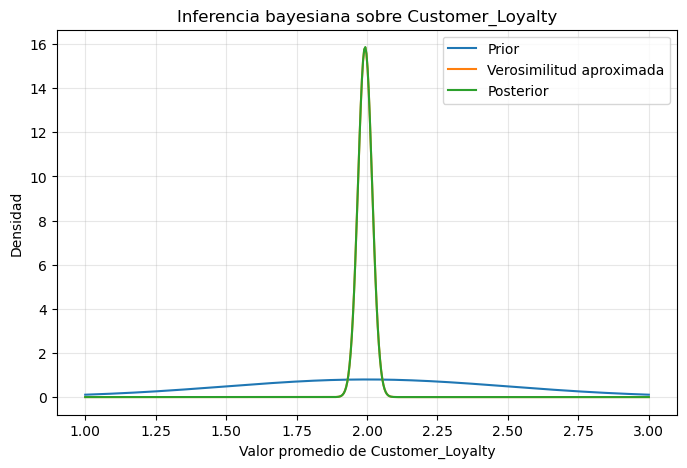

In [27]:
# Visualización de prior, verosimilitud y posterior

x_vals = np.linspace(1, 3, 500)

prior_dist = stats.norm.pdf(x_vals, prior_mean, prior_std)
likelihood_dist = stats.norm.pdf(x_vals, media_loyalty, std_loyalty / np.sqrt(n_loyalty))
posterior_dist = stats.norm.pdf(x_vals, posterior_mean, posterior_std)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, prior_dist, label="Prior")
plt.plot(x_vals, likelihood_dist, label="Verosimilitud aproximada")
plt.plot(x_vals, posterior_dist, label="Posterior")

plt.title("Inferencia bayesiana sobre Customer_Loyalty")
plt.xlabel("Valor promedio de Customer_Loyalty")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.4 Simulación de estimación bayesiana

In [28]:
# Simulación Monte Carlo desde la posterior

np.random.seed(123)

# Número de simulaciones
n_sim = 10000

# Simulación de muestras desde la posterior normal
posterior_samples = np.random.normal(
    loc=posterior_mean,
    scale=posterior_std,
    size=n_sim
)

# Resumen de simulación
media_simulada = posterior_samples.mean()
std_simulada = posterior_samples.std(ddof=1)
ic_cred_95 = np.percentile(posterior_samples, [2.5, 97.5])

print("Número de simulaciones:", n_sim)
print("Media simulada posterior:", round(media_simulada, 4))
print("Desviación estándar simulada:", round(std_simulada, 4))
print("Intervalo de credibilidad del 95%:", np.round(ic_cred_95, 4))

Número de simulaciones: 10000
Media simulada posterior: 1.9933
Desviación estándar simulada: 0.0251
Intervalo de credibilidad del 95%: [1.9445 2.0423]


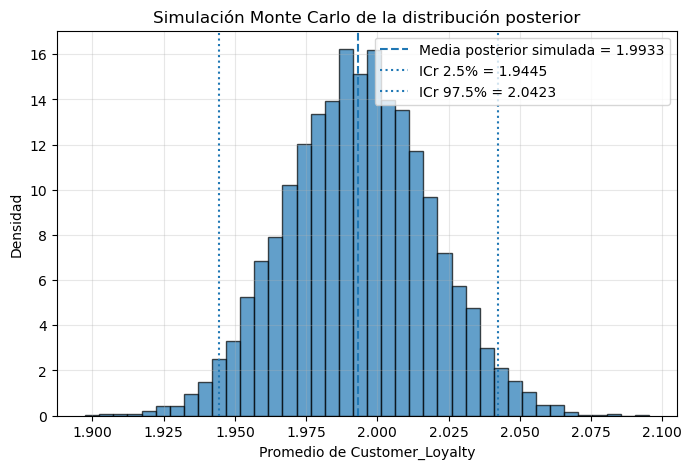

In [29]:
# Visualización de la distribución posterior simulada

plt.figure(figsize=(8, 5))
plt.hist(posterior_samples, bins=40, density=True, alpha=0.7, edgecolor="black")
plt.axvline(media_simulada, linestyle="--", label=f"Media posterior simulada = {media_simulada:.4f}")
plt.axvline(ic_cred_95[0], linestyle=":", label=f"ICr 2.5% = {ic_cred_95[0]:.4f}")
plt.axvline(ic_cred_95[1], linestyle=":", label=f"ICr 97.5% = {ic_cred_95[1]:.4f}")

plt.title("Simulación Monte Carlo de la distribución posterior")
plt.xlabel("Promedio de Customer_Loyalty")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

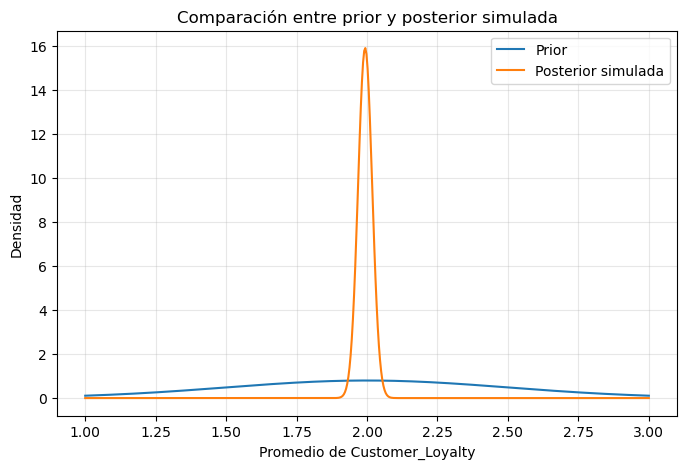

In [30]:

# Comparación entre prior y posterior simulada
plt.figure(figsize=(8, 5))

x_vals = np.linspace(1, 3, 500)
prior_curve = stats.norm.pdf(x_vals, prior_mean, prior_std)
posterior_curve = stats.norm.pdf(x_vals, media_simulada, std_simulada)

plt.plot(x_vals, prior_curve, label="Prior")
plt.plot(x_vals, posterior_curve, label="Posterior simulada")

plt.title("Comparación entre prior y posterior simulada")
plt.xlabel("Promedio de Customer_Loyalty")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.5 Modelo jerárquico bayesiano

In [31]:
# Resumen descriptivo por grupo

# Variable de respuesta y variable agrupadora
respuesta = "Trip_Rating"
grupo = "Vehicle_Type"

# Resumen descriptivo por tipo de vehículo
resumen_grupos = df_model.groupby(grupo)[respuesta].agg(
    n="count",
    media="mean",
    desviacion="std"
).reset_index()

resumen_grupos

,Vehicle_Type,n,media,desviacion
0,Economy,478,4.2584,0.4335
1,Premium,522,4.2562,0.4383


In [32]:
# Modelo jerárquico bayesiano aproximado

# Parámetros globales observados
media_global = df_model[respuesta].mean()
std_global = df_model[respuesta].std(ddof=1)
n_total = len(df_model)

print("Media global observada de Trip_Rating:", round(media_global, 4))
print("Desviación estándar global observada:", round(std_global, 4))
print("Número total de observaciones:", n_total)

# Prior general para las medias de grupo
prior_global_mean = media_global
prior_global_std = std_global

print("\nPrior general para las medias de grupo:")
print("Media prior global:", round(prior_global_mean, 4))
print("Desviación estándar prior global:", round(prior_global_std, 4))

Media global observada de Trip_Rating: 4.2572
Desviación estándar global observada: 0.4358
Número total de observaciones: 1000

Prior general para las medias de grupo:
Media prior global: 4.2572
Desviación estándar prior global: 0.4358


In [33]:
# 28. Simulación posterior de medias por grupo
np.random.seed(123)

n_sim = 10000
posteriores_grupo = {}
resultados_jerarquicos = []

for tipo in resumen_grupos[grupo]:
    datos_grupo = df_model[df_model[grupo] == tipo][respuesta].dropna()
    
    n_g = len(datos_grupo)
    media_g = datos_grupo.mean()
    std_g = datos_grupo.std(ddof=1)
    
    # Varianza de la muestra y de la prior
    sigma2_g = std_g**2
    tau2 = prior_global_std**2
    
    # Posterior normal aproximada para la media del grupo
    post_var_g = 1 / ((1 / tau2) + (n_g / sigma2_g))
    post_mean_g = post_var_g * ((prior_global_mean / tau2) + (n_g * media_g / sigma2_g))
    post_std_g = np.sqrt(post_var_g)
    
    # Simulación Monte Carlo desde la posterior del grupo
    sim_g = np.random.normal(post_mean_g, post_std_g, n_sim)
    posteriores_grupo[tipo] = sim_g
    
    # Intervalo creíble del 95%
    ic_g = np.percentile(sim_g, [2.5, 97.5])
    
    resultados_jerarquicos.append({
        "Grupo": tipo,
        "n": n_g,
        "Media observada": media_g,
        "Media posterior": post_mean_g,
        "Desv. posterior": post_std_g,
        "IC 95% inferior": ic_g[0],
        "IC 95% superior": ic_g[1]
    })

tabla_jerarquica = pd.DataFrame(resultados_jerarquicos)
tabla_jerarquica

,Grupo,n,Media observada,Media posterior,Desv. posterior,IC 95% inferior,IC 95% superior
0,Economy,478,4.2584,4.2584,0.0198,4.2201,4.2972
1,Premium,522,4.2562,4.2562,0.0192,4.2196,4.2938


In [34]:
# Posterior general de Trip_Rating

# Prior general informativa centrada en 4, coherente con el umbral de servicio excelente
prior_mean_rating = 4
prior_std_rating = 0.5

sigma2_global = std_global**2
tau2_global = prior_std_rating**2

post_var_global = 1 / ((1 / tau2_global) + (n_total / sigma2_global))
post_mean_global = post_var_global * ((prior_mean_rating / tau2_global) + (n_total * media_global / sigma2_global))
post_std_global = np.sqrt(post_var_global)

sim_global = np.random.normal(post_mean_global, post_std_global, n_sim)
ic_global = np.percentile(sim_global, [2.5, 97.5])

print("Posterior general de Trip_Rating")
print("Media posterior general:", round(post_mean_global, 4))
print("Desviación estándar posterior general:", round(post_std_global, 4))
print("Intervalo creíble 95%:", np.round(ic_global, 4))

Posterior general de Trip_Rating
Media posterior general: 4.257
Desviación estándar posterior general: 0.0138
Intervalo creíble 95%: [4.2304 4.2841]


In [35]:
# Tabla final de parámetros jerárquicos

fila_global = pd.DataFrame([{
    "Grupo": "Posterior general",
    "n": n_total,
    "Media observada": media_global,
    "Media posterior": post_mean_global,
    "Desv. posterior": post_std_global,
    "IC 95% inferior": ic_global[0],
    "IC 95% superior": ic_global[1]
}])

tabla_jerarquica_final = pd.concat([tabla_jerarquica, fila_global], ignore_index=True)

tabla_jerarquica_final

,Grupo,n,Media observada,Media posterior,Desv. posterior,IC 95% inferior,IC 95% superior
0,Economy,478,4.2584,4.2584,0.0198,4.2201,4.2972
1,Premium,522,4.2562,4.2562,0.0192,4.2196,4.2938
2,Posterior general,1000,4.2572,4.2570,0.0138,4.2304,4.2841


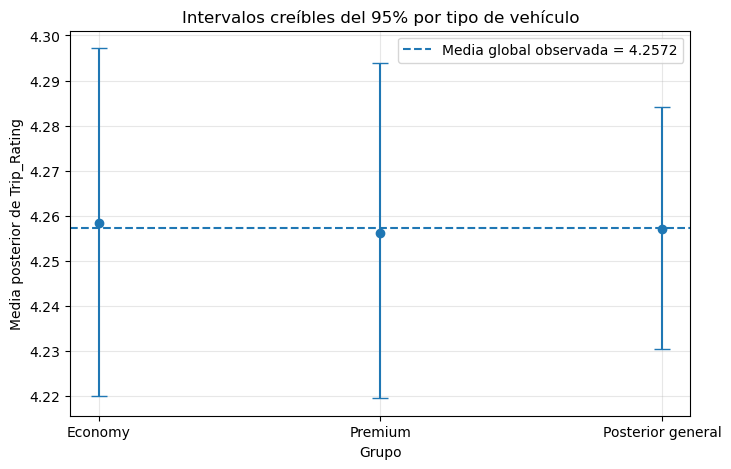

In [36]:
# Visualización de intervalos creíbles por grupo

plt.figure(figsize=(8, 5))

x_pos = np.arange(len(tabla_jerarquica_final))

medias = tabla_jerarquica_final["Media posterior"]
errores_inf = medias - tabla_jerarquica_final["IC 95% inferior"]
errores_sup = tabla_jerarquica_final["IC 95% superior"] - medias

plt.errorbar(
    x_pos,
    medias,
    yerr=[errores_inf, errores_sup],
    fmt="o",
    capsize=6
)

plt.xticks(x_pos, tabla_jerarquica_final["Grupo"])
plt.axhline(media_global, linestyle="--", label=f"Media global observada = {media_global:.4f}")

plt.title("Intervalos creíbles del 95% por tipo de vehículo")
plt.xlabel("Grupo")
plt.ylabel("Media posterior de Trip_Rating")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

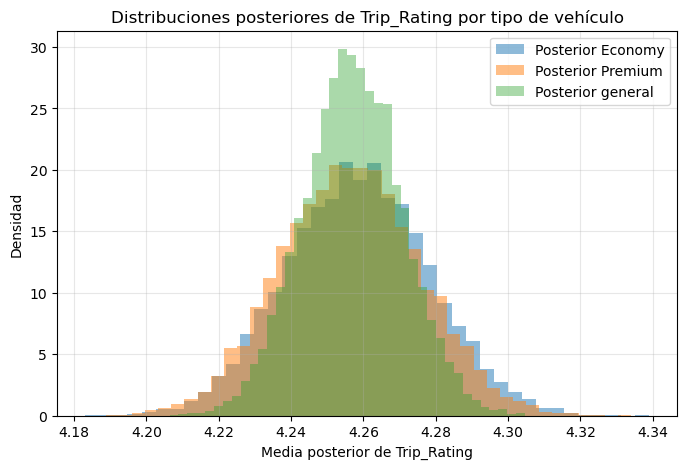

In [37]:
# Distribuciones posteriores por grupo

plt.figure(figsize=(8, 5))

for tipo, simulaciones in posteriores_grupo.items():
    plt.hist(simulaciones, bins=40, density=True, alpha=0.5, label=f"Posterior {tipo}")

plt.hist(sim_global, bins=40, density=True, alpha=0.4, label="Posterior general")

plt.title("Distribuciones posteriores de Trip_Rating por tipo de vehículo")
plt.xlabel("Media posterior de Trip_Rating")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()